### Preprocessing Step 4: Data Imputation
 
We will use the IterativeImputer from scikitlearn (MICE). 

In [1]:
from pathlib import Path
import os
from tqdm import tqdm
from glob import glob
import pandas as pd
import numpy as np
import re
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import seaborn as sns
from helperfunctions.intern_constants import TS_COL, WT_ID, ANY, SIGNAL_COL, PATH_PENMANSHIEL
from typing import Optional, Tuple
from concurrent.futures import ThreadPoolExecutor, as_completed

### Some preparations to start the preprocessing

In [2]:
path = Path("Penmanshiel")
processed_data_path = os.path.join(path, "processed_data")
imputed_path = os.path.join(processed_data_path, "signal_imputation")
masks_path = os.path.join(imputed_path, "masks")
os.makedirs(imputed_path, exist_ok=True)
os.makedirs(masks_path, exist_ok=True)

paths = [fn for fn in os.listdir(processed_data_path)]

for p in paths:
    print(f"{p}")
    
excludeColList = ['WT_ID', 'Date and time']

#Get the Penmanshiel_WT_dataSignalMapping file and put it into the Penmashiel folder.
pathToValues = os.path.join(path,"Penmanshiel_WT_dataSignalMapping.xlsx")    

signal_imputation
WT_ID_10_selected_signals.csv
WT_ID_11_selected_signals.csv
WT_ID_12_selected_signals.csv
WT_ID_13_selected_signals.csv
WT_ID_14_selected_signals.csv
WT_ID_15_selected_signals.csv
WT_ID_1_selected_signals.csv
WT_ID_2_selected_signals.csv
WT_ID_4_selected_signals.csv
WT_ID_5_selected_signals.csv
WT_ID_6_selected_signals.csv
WT_ID_7_selected_signals.csv
WT_ID_8_selected_signals.csv
WT_ID_9_selected_signals.csv


In [3]:
preStep4_dict = {
    "PenmanshielPath"       : path,
    "processed_data_path"   : processed_data_path,
    "imputed_path"          : imputed_path,
    "paths"                 : paths,
    "excludeColList"        : excludeColList,
    "pathToValues"          : pathToValues,
    "masks_path"            : masks_path
}

### Pick columns to manipulate

In [4]:
def pickCols(df:pd.DataFrame, excludeColList: list)-> list:
    return [sig for sig in df.columns if sig not in excludeColList ]

We will use the min and max values from each signal to set the iterative imputer from scikit learn.

In [5]:
def _to_float(x):
    x = str(x).strip().replace(",",".")
    num = pd.to_numeric(x, errors="coerce")
    return num

def createMinMaxVals(pathToValues: Path, colList: list ) -> Tuple:
   
    minmax_df = pd.read_excel(pathToValues, dtype=str).apply(lambda s: s.str.strip())
    
    
    # delete suffix = ["(m/s)","(°)","(kW)","(°C)","(A)","(RPM)","(bar)", "(mm/ss)"] from col entry
    pattern = r"\s*\((?:m/s|°|kW|°C|A|RPM|bar|mm/ss)\)$"
    cols_mod = [re.sub(pattern,"",sig).strip() for sig in colList]
    #manual correction
    #cols_mod[12] = cols_mod[12] + " (converter)"
    mmf_df = minmax_df[minmax_df["TitleGreenbyte"].isin(cols_mod)]

    
    min_vals = []
    max_vals = []
    # we want the same ordering of min max values as the entries in the data table
    # cols_mod contains the signals in the right order as in the data table.
    for item in cols_mod:
        #print(f"item = {item}")
        minmax = mmf_df.loc[mmf_df["TitleGreenbyte"]==item,["MinValue", "MaxValue"]].values[0]
        lo, hi = map(_to_float, minmax)
        lo = lo if pd.notna(lo) else -np.inf
        hi = hi if pd.notna(hi) else np.inf
        min_vals.append(lo)
        max_vals.append(hi)
  
    assert len(min_vals) == len(max_vals)
    
    return (min_vals, max_vals)

In [6]:
def createImputer(min_vals:list, max_vals:list)-> IterativeImputer:
    imputer = IterativeImputer(
        initial_strategy="median",
        random_state=42,
        max_iter=20,
        tol=1e-3,
        min_value=min_vals,
        max_value= max_vals
    )
    return imputer

def impute(df: pd.DataFrame, imputer: IterativeImputer, colsToSelect: list)-> pd.DataFrame:
    df_subset = df[colsToSelect]
    imputed = imputer.fit_transform(df_subset)
    df_imputed = df.copy()
    df_imputed[colsToSelect] = imputed
    
    assert df_imputed.isnull().sum().sum() == 0
    return df_imputed
    

### Step 4:

In [7]:
try:
    import pyarrow
    _CSV_ENGINE = "pyarrow"
    _HAVE_PA = True
except Exception:
    _CSV_ENGINE = None
    _HAVE_PA = False
    
def _process_one_file_thread(
    file_path: Path,
    preStep4_dict: dict,
)-> Tuple[Path, bool, str | None]:
    try:
        file_path =Path(file_path)
        cols_all = pd.read_csv(file_path, nrows=0).columns.to_list()
        exclude = set(preStep4_dict["excludeColList"])
        must_have ={TS_COL, WT_ID}
        
        include_cols = [c for c in cols_all if (c not in exclude) or (c in must_have)]
        
        read_kwargs = {
            "parse_dates": [TS_COL],
            "usecols": include_cols
        }
        if _CSV_ENGINE:
            read_kwargs["engine"] = _CSV_ENGINE
            read_kwargs["dtype_backend"] = "pyarrow"
            
        df = pd.read_csv(file_path, **read_kwargs)
        colList = pickCols(df, preStep4_dict["excludeColList"])
        
        mask = df[colList].isna().to_numpy() # (rows, signals) : bool
        
        rows, cols = np.where(mask) # (rows, signals)
        
        ts_arr = pd.to_datetime(df[TS_COL].to_numpy()) # (rows,)
        wt_arr = df[WT_ID].to_numpy() # (rows,)
        sig_arr = np.array(colList, dtype=object) # (signals,)
        
        only_imputed = pd.DataFrame({
            TS_COL: ts_arr[rows],
            WT_ID: wt_arr[rows],
            SIGNAL_COL: sig_arr[cols],
        })
        
        any_rows = np.where(mask.any(axis=1))[0]
        
        if any_rows.size:
            any_imputed = pd.DataFrame({
                TS_COL: ts_arr[any_rows],
                WT_ID: wt_arr[any_rows],
                SIGNAL_COL: ANY,
            })
            log_imputed = pd.concat([only_imputed, any_imputed], axis=0, ignore_index=True)
        
        else:
            log_imputed = only_imputed
        
        if not log_imputed.empty:
            log_imputed = log_imputed.sort_values(TS_COL).reset_index(drop=True)
            
        masks_dir = Path(preStep4_dict["masks_path"])
        masks_dir.mkdir(parents=True, exist_ok=True)
        imputed_dir = Path(preStep4_dict["imputed_path"])
        imputed_dir.mkdir(parents=True, exist_ok=True)
            
        stem = file_path.stem
            
        if _HAVE_PA:
            log_path = masks_dir / f"{stem}_nan_log.parquet"
            log_imputed.to_parquet(log_path, index=False)
        else:
            # log_path = masks_dir / f"{stem}_nan_log.csv"
            # df_impute_log.to_csv(log_path, index=False)
            raise ValueError(f"pyarrow not installed. Make sure to install pyarrow")
        
        (min_vals, max_vals) = createMinMaxVals(preStep4_dict["pathToValues"],colList)
        imputer = createImputer(min_vals, max_vals)
        df_imputed = impute(df,imputer,colList)
        
        if df_imputed.isna().values.any():
            raise ValueError("Imputed DataFrame contains still NaNs.")
        
        out_path = imputed_dir / f"{stem}_imputed.csv"
        df_imputed.to_csv(out_path, index=False)
        
        return (file_path, True, None)
            
    except Exception as e:
        import traceback
        return (file_path, False, f"{e}\n{traceback.format_exc()}")

In [8]:
def preprocessing_step4(preStep4_dict: dict,
                        max_workers: Optional[int] = None)-> None:
    
    
    files = glob(os.path.join(preStep4_dict["processed_data_path"], "*.csv"))

    if not files:
        print(f"No csv files in {preStep4_dict['processed_data_path']}")
        return
    
    if max_workers is None:
        cpu = os.cpu_count() or 1
        max_workers = min(len(files), max(2, cpu * 2), 8) # always 8 - 
    
    print(f"[Threads + {'pyarrow' if _HAVE_PA else 'pandas'}] Start with {max_workers} Workers for {len(files)} files.")
        
    results = []
    
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        future_to_file  = {ex.submit(_process_one_file_thread, f, preStep4_dict) : f for f in files}
        for fut in tqdm(as_completed(future_to_file), total=len(future_to_file), desc="processing"):
            results.append(fut.result())
    
    n_ok = sum(1 for _, ok, _ in results if ok)
    n_fail = len(results) - n_ok
    
    print(f"Fertig: {n_ok}, {n_fail} fehlgeschlagen.")
    
    if n_fail:
        print("\nFehlerdetails:")
        for f, ok, err in results:
            if not ok:
                print(f"-{f}:\n{err}\n")
        

Executing this step might take some time (~80 min)

In [9]:
## check file existance
p = Path(PATH_PENMANSHIEL / "Penmanshiel_WT_dataSignalMapping.xlsx")
if not p.exists():
    print("Make sure the file Penmanshiel_WT_dataSignalMapping.xlsx is in the Penmanshiel folder.")
else:
    preprocessing_step4(preStep4_dict)

[Threads + pyarrow] Start with 8 Workers for 14 files.


processing:   0%|          | 0/14 [00:00<?, ?it/s]

processing:  14%|█▍        | 2/14 [1:16:10<7:31:40, 2258.36s/it]c:\Users\admin\Uni\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\admin\Uni\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\admin\Uni\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\admin\Uni\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not re

Fertig: 14, 0 fehlgeschlagen.


### visual check of imputed data

  0%|          | 0/14 [00:00<?, ?it/s]

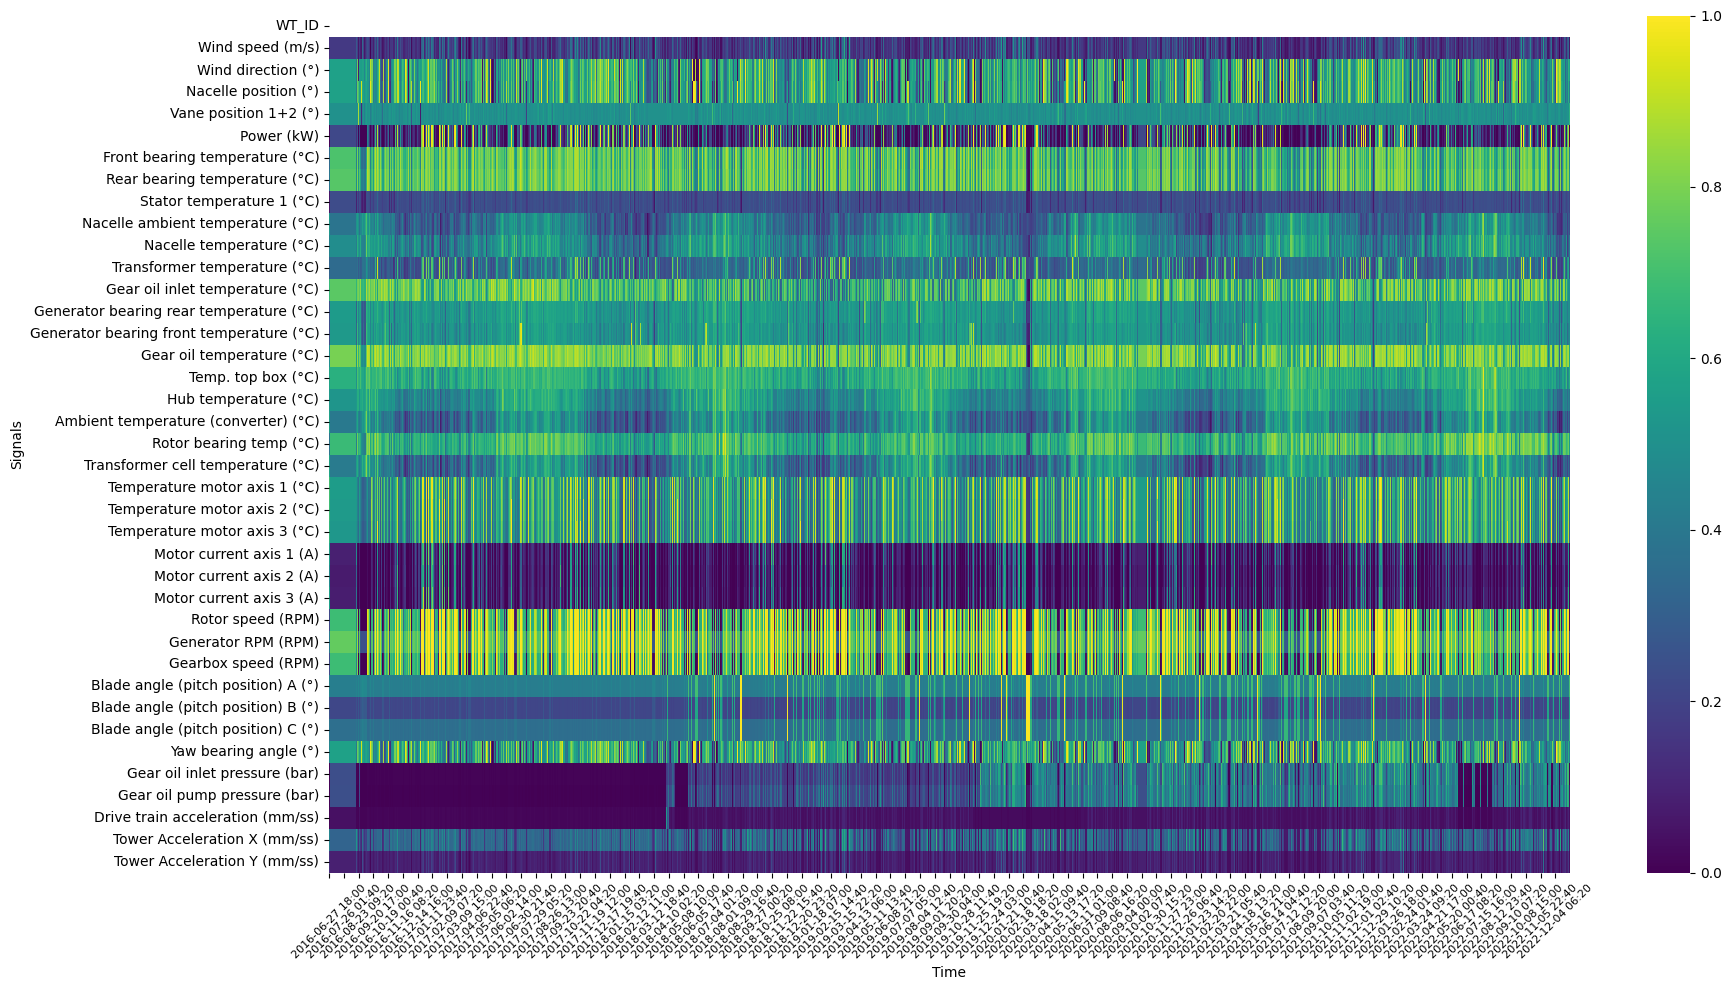

  7%|▋         | 1/14 [00:47<10:15, 47.32s/it]

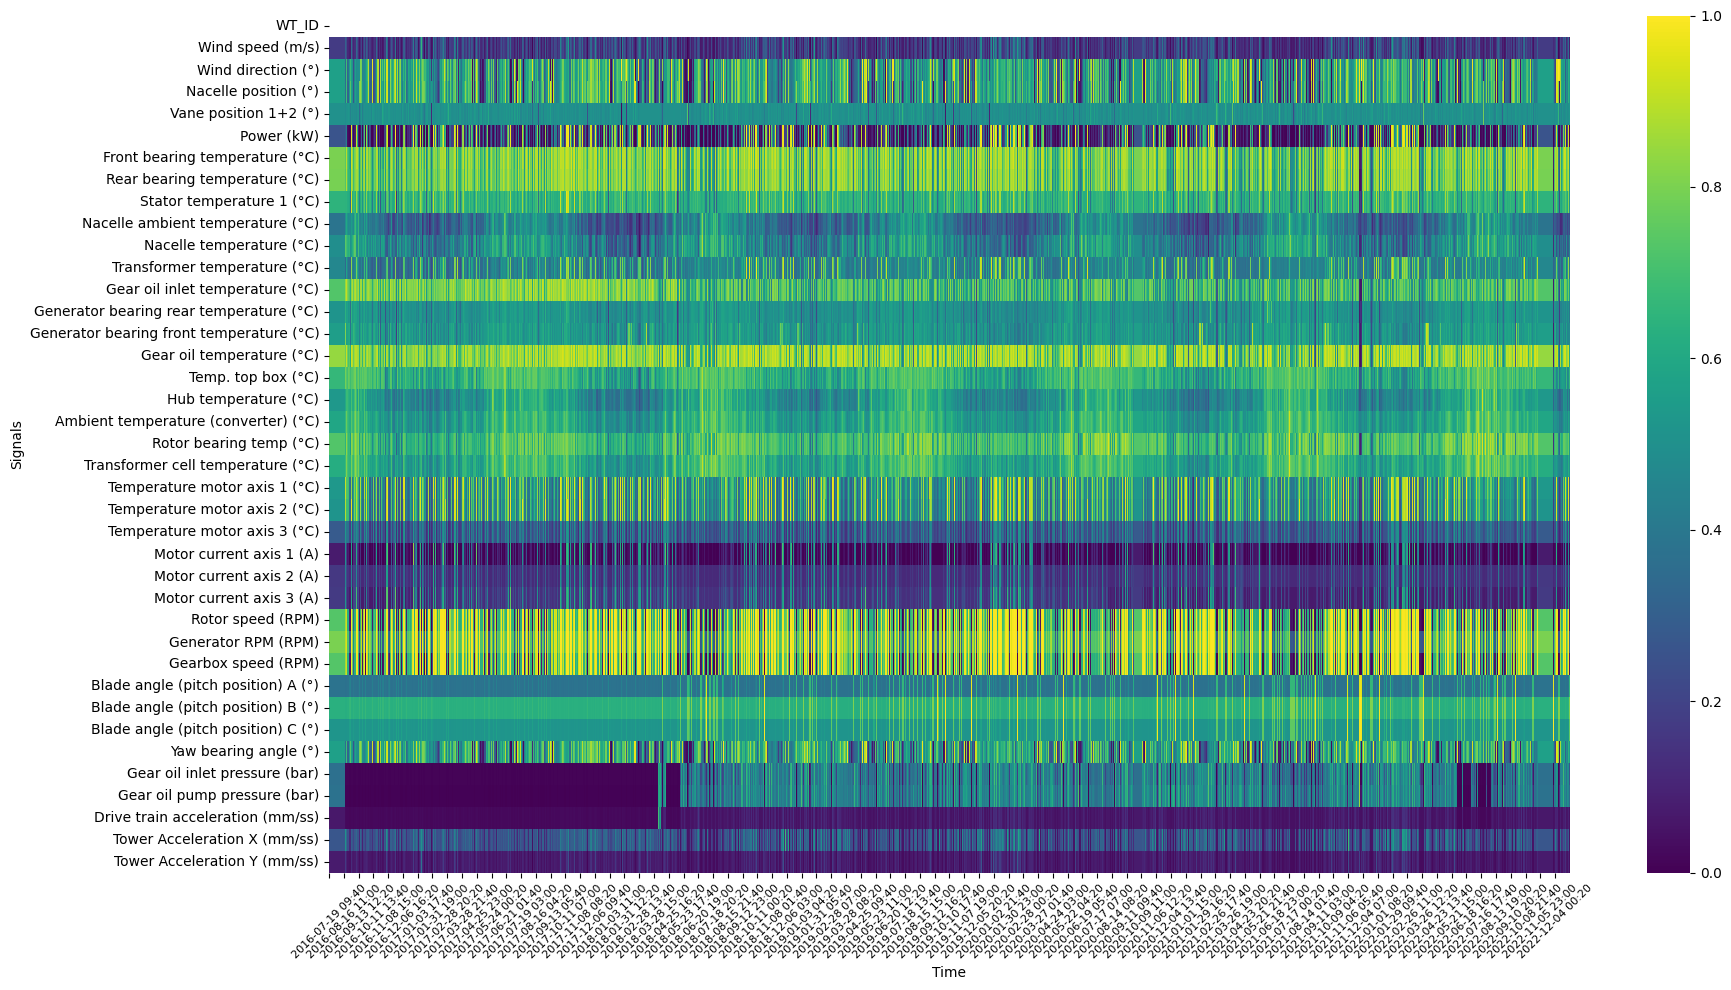

 14%|█▍        | 2/14 [01:26<08:32, 42.72s/it]

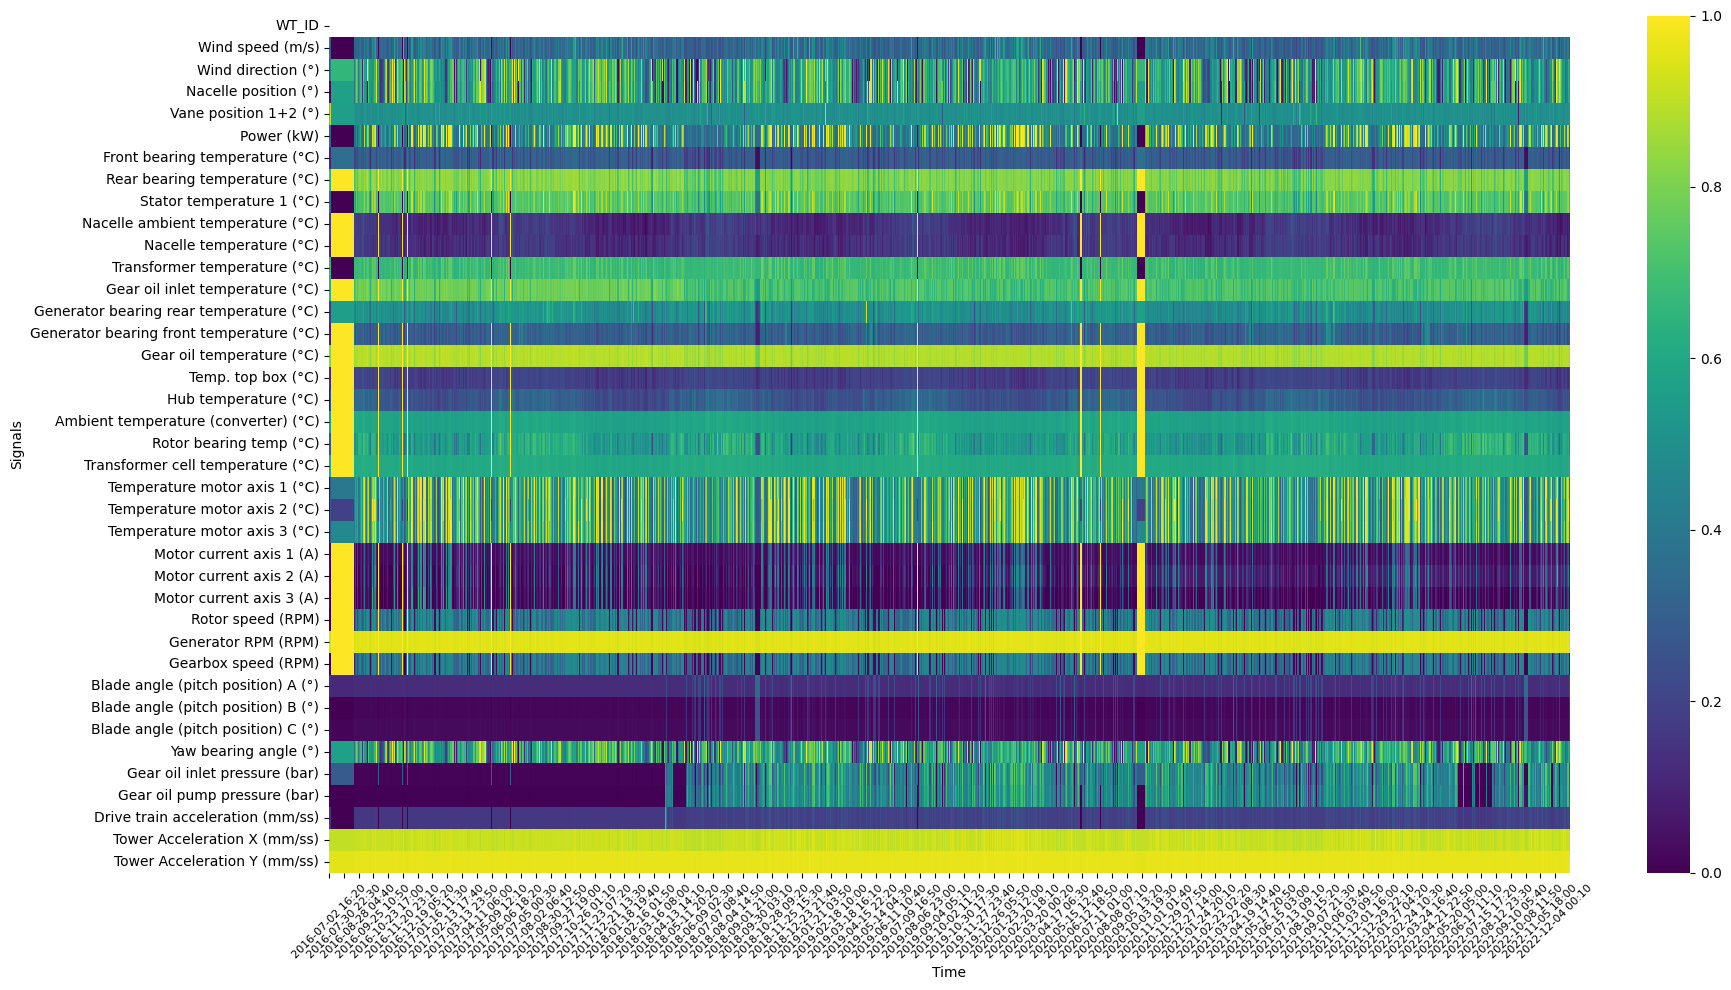

 21%|██▏       | 3/14 [02:09<07:49, 42.65s/it]

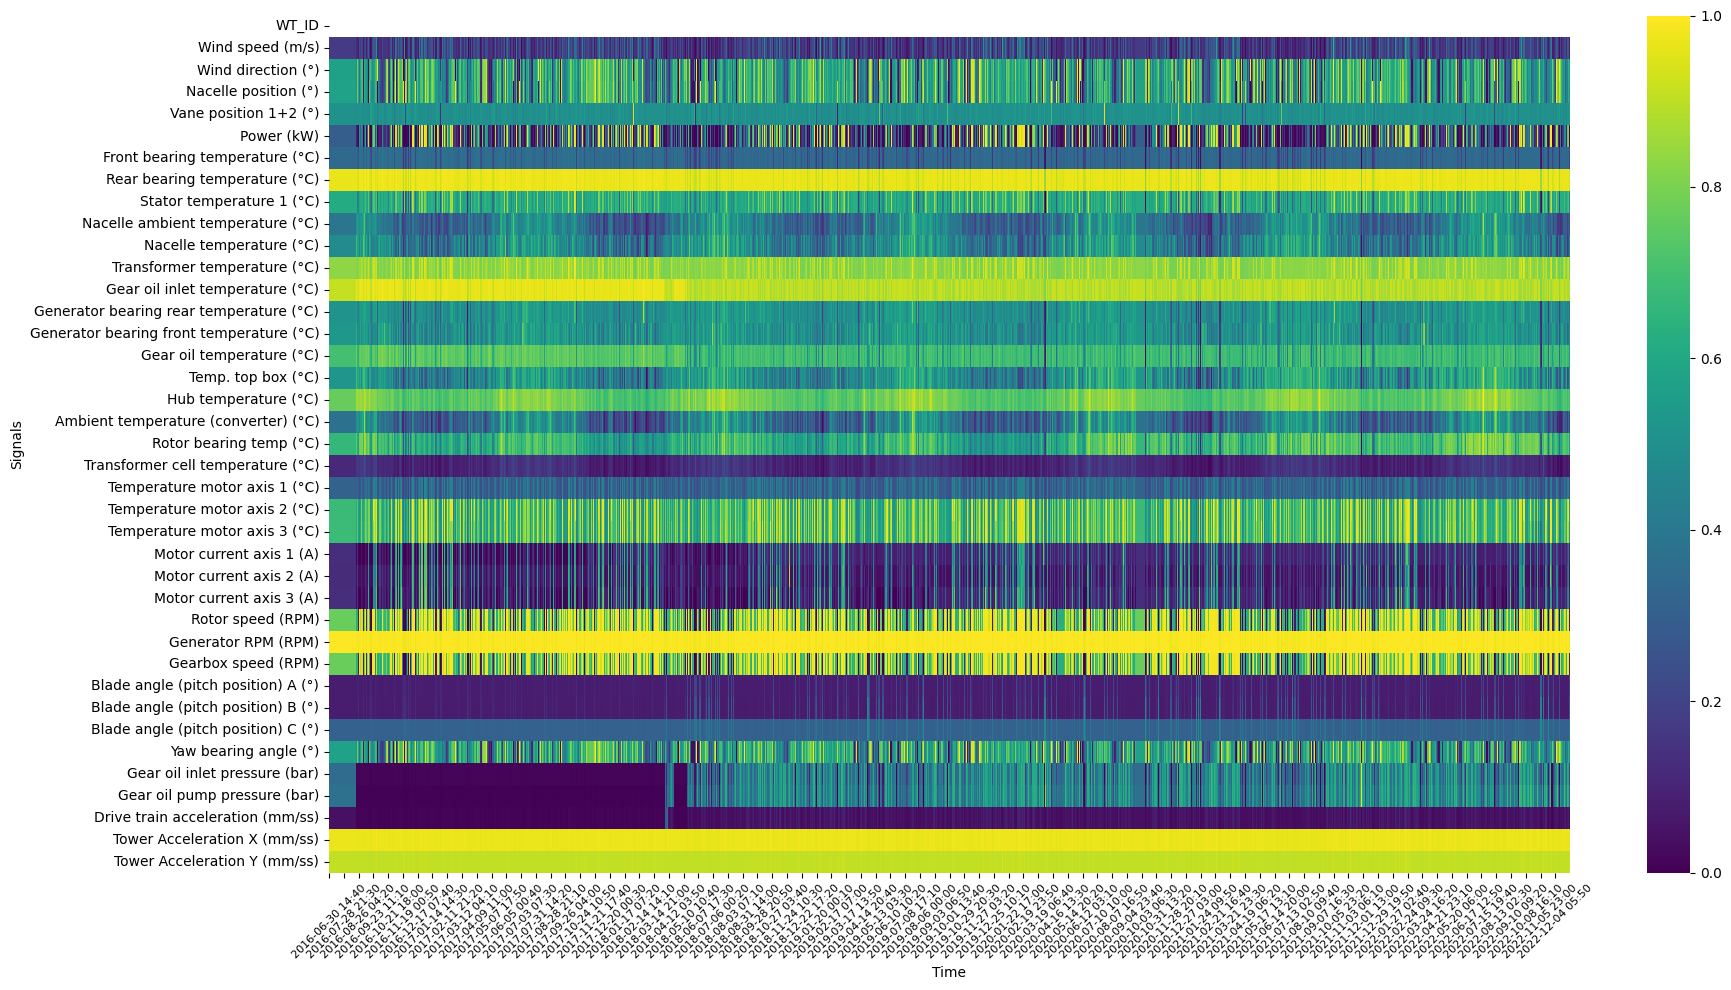

 29%|██▊       | 4/14 [02:41<06:24, 38.44s/it]

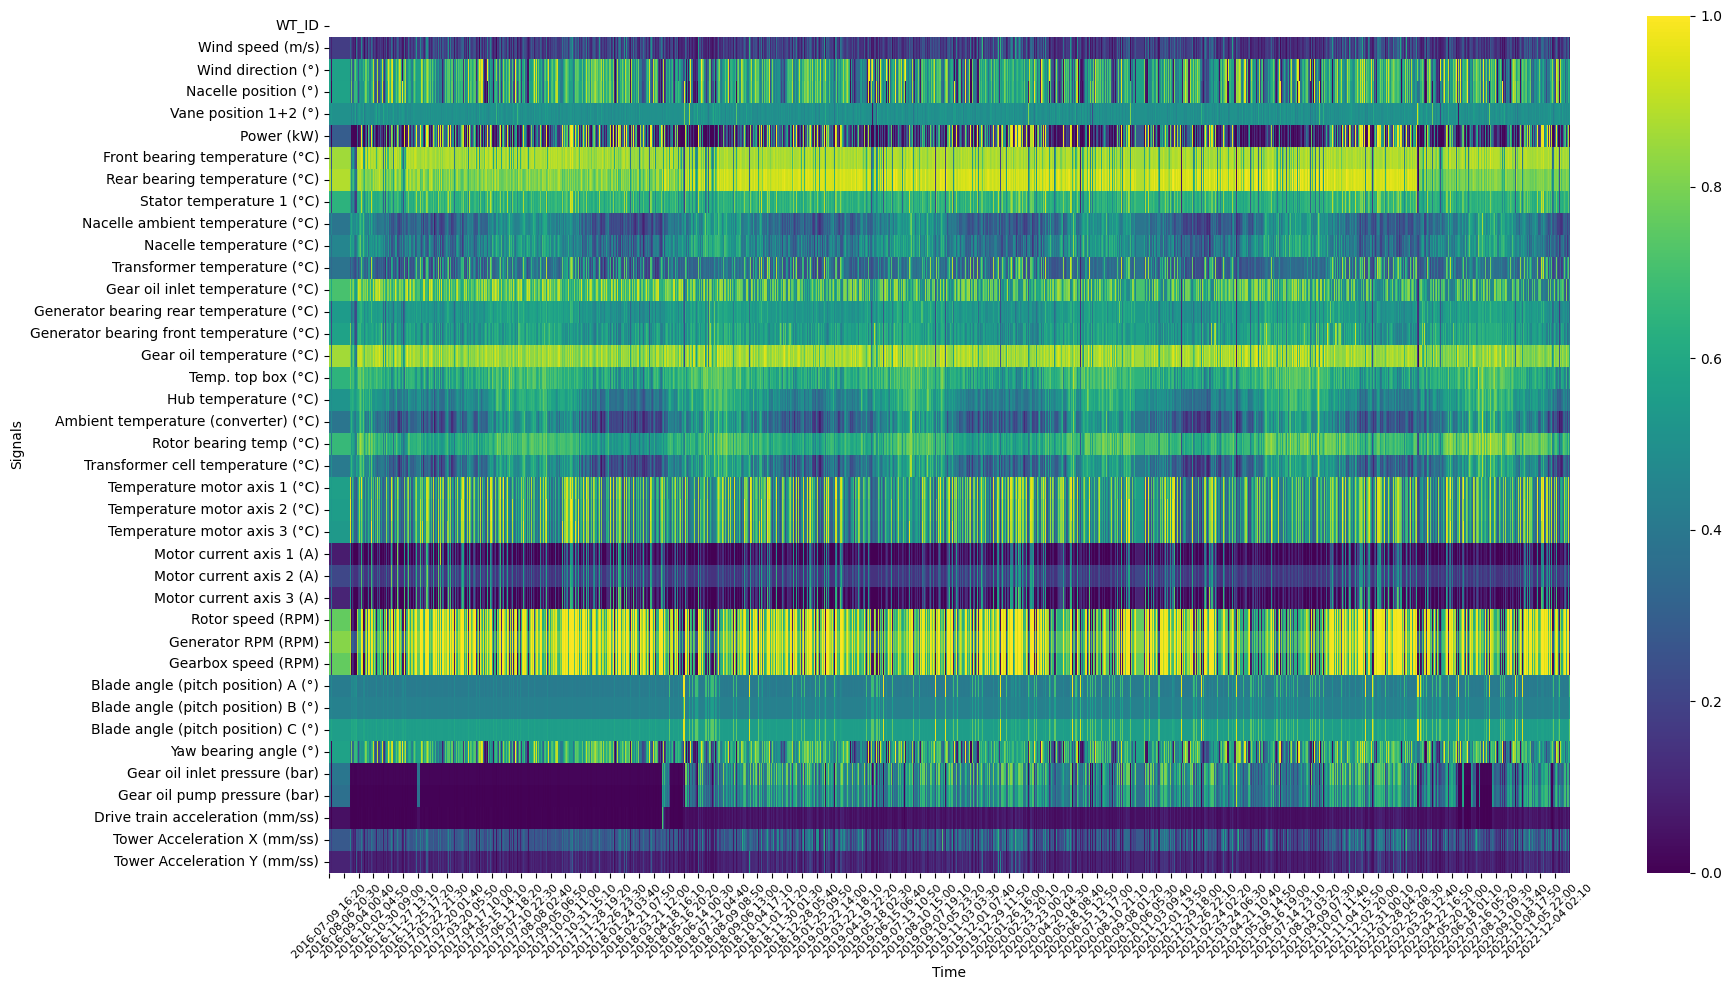

 36%|███▌      | 5/14 [03:14<05:29, 36.63s/it]

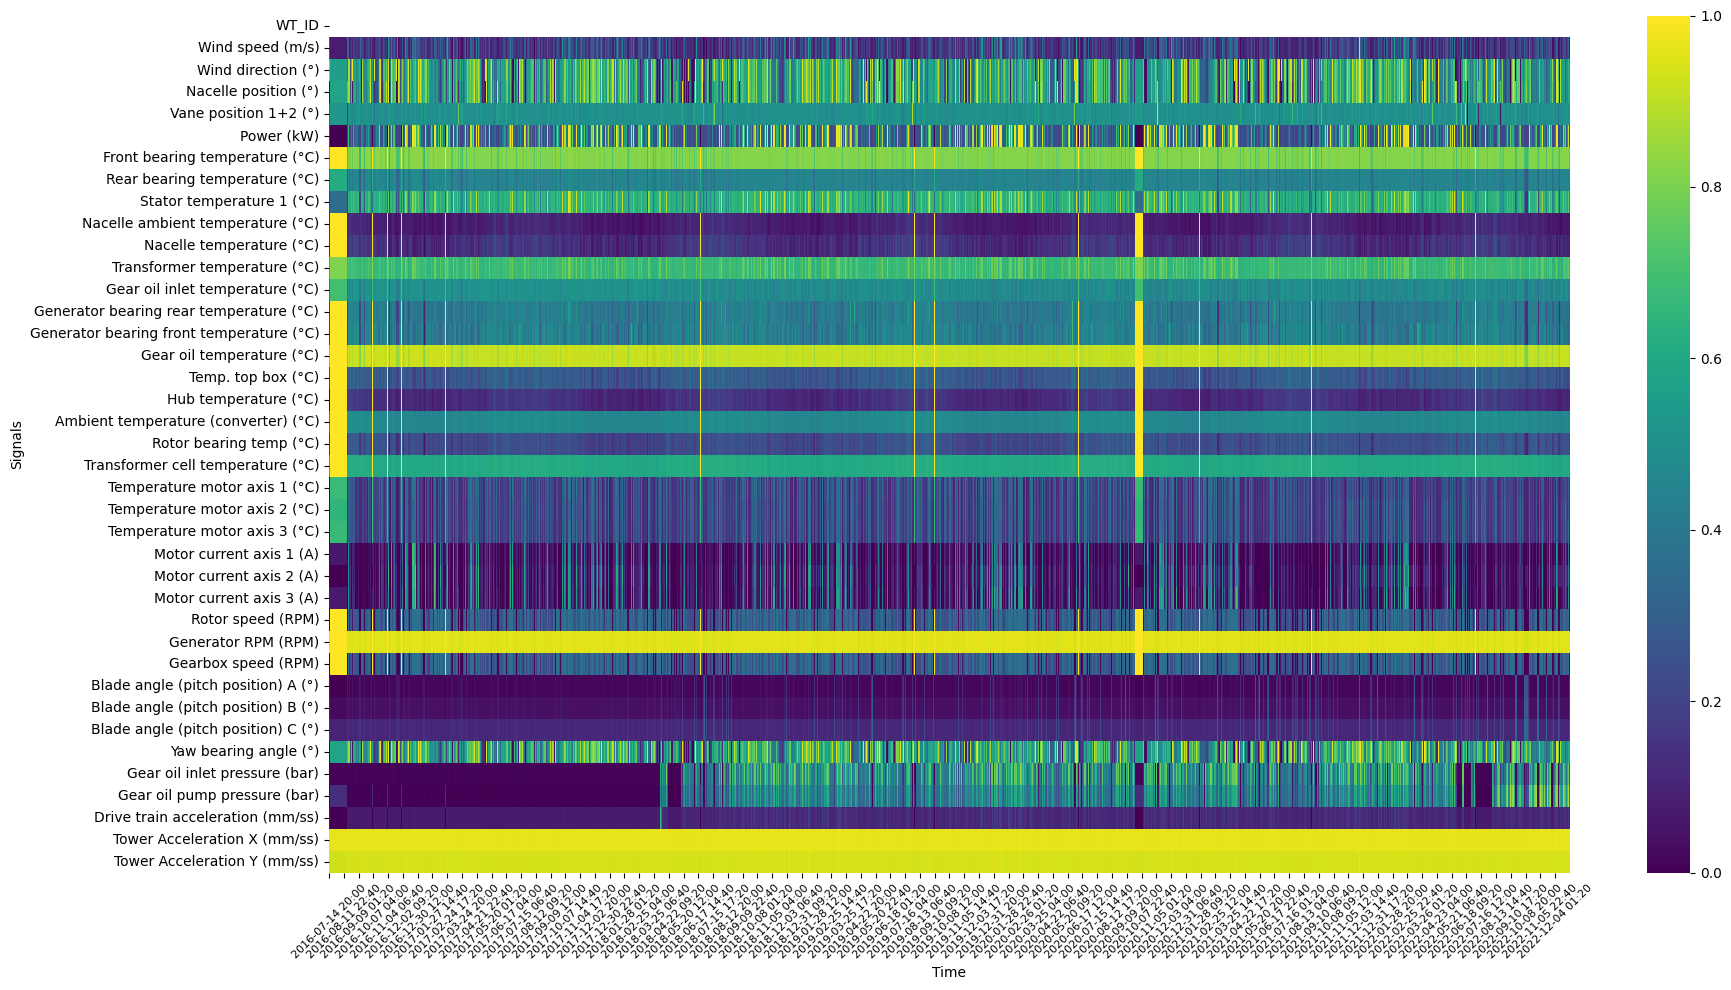

 43%|████▎     | 6/14 [03:47<04:42, 35.29s/it]

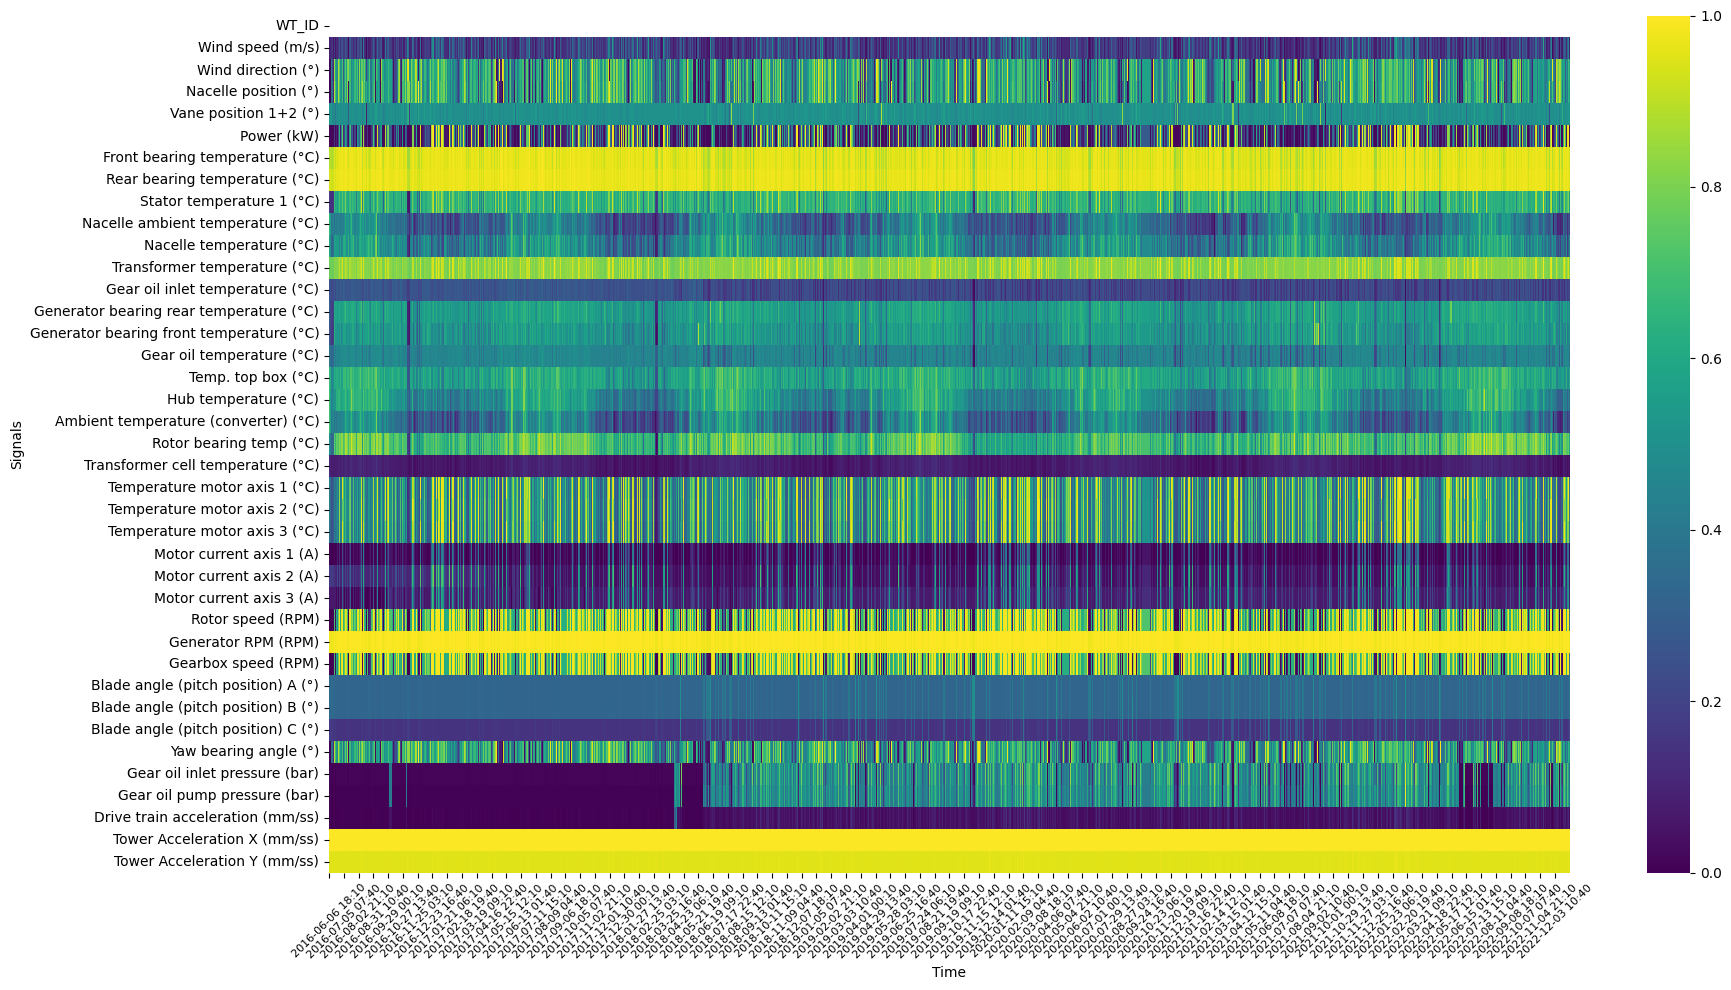

 50%|█████     | 7/14 [04:22<04:06, 35.21s/it]

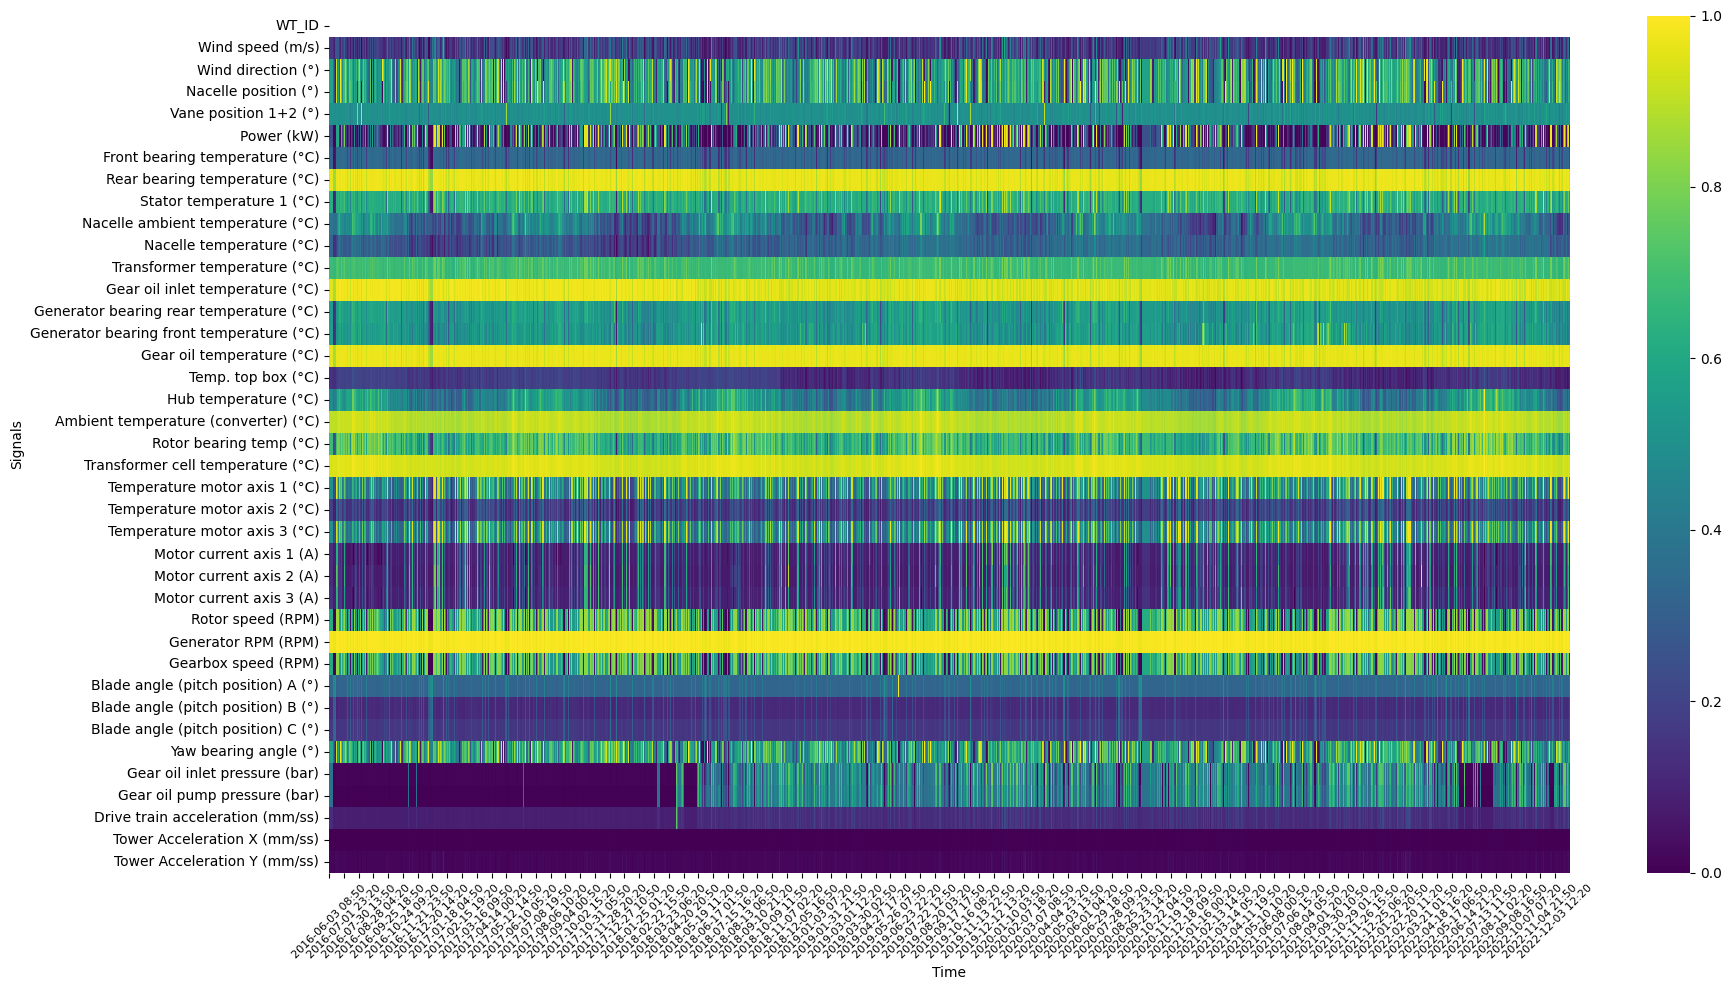

 57%|█████▋    | 8/14 [05:01<03:38, 36.35s/it]

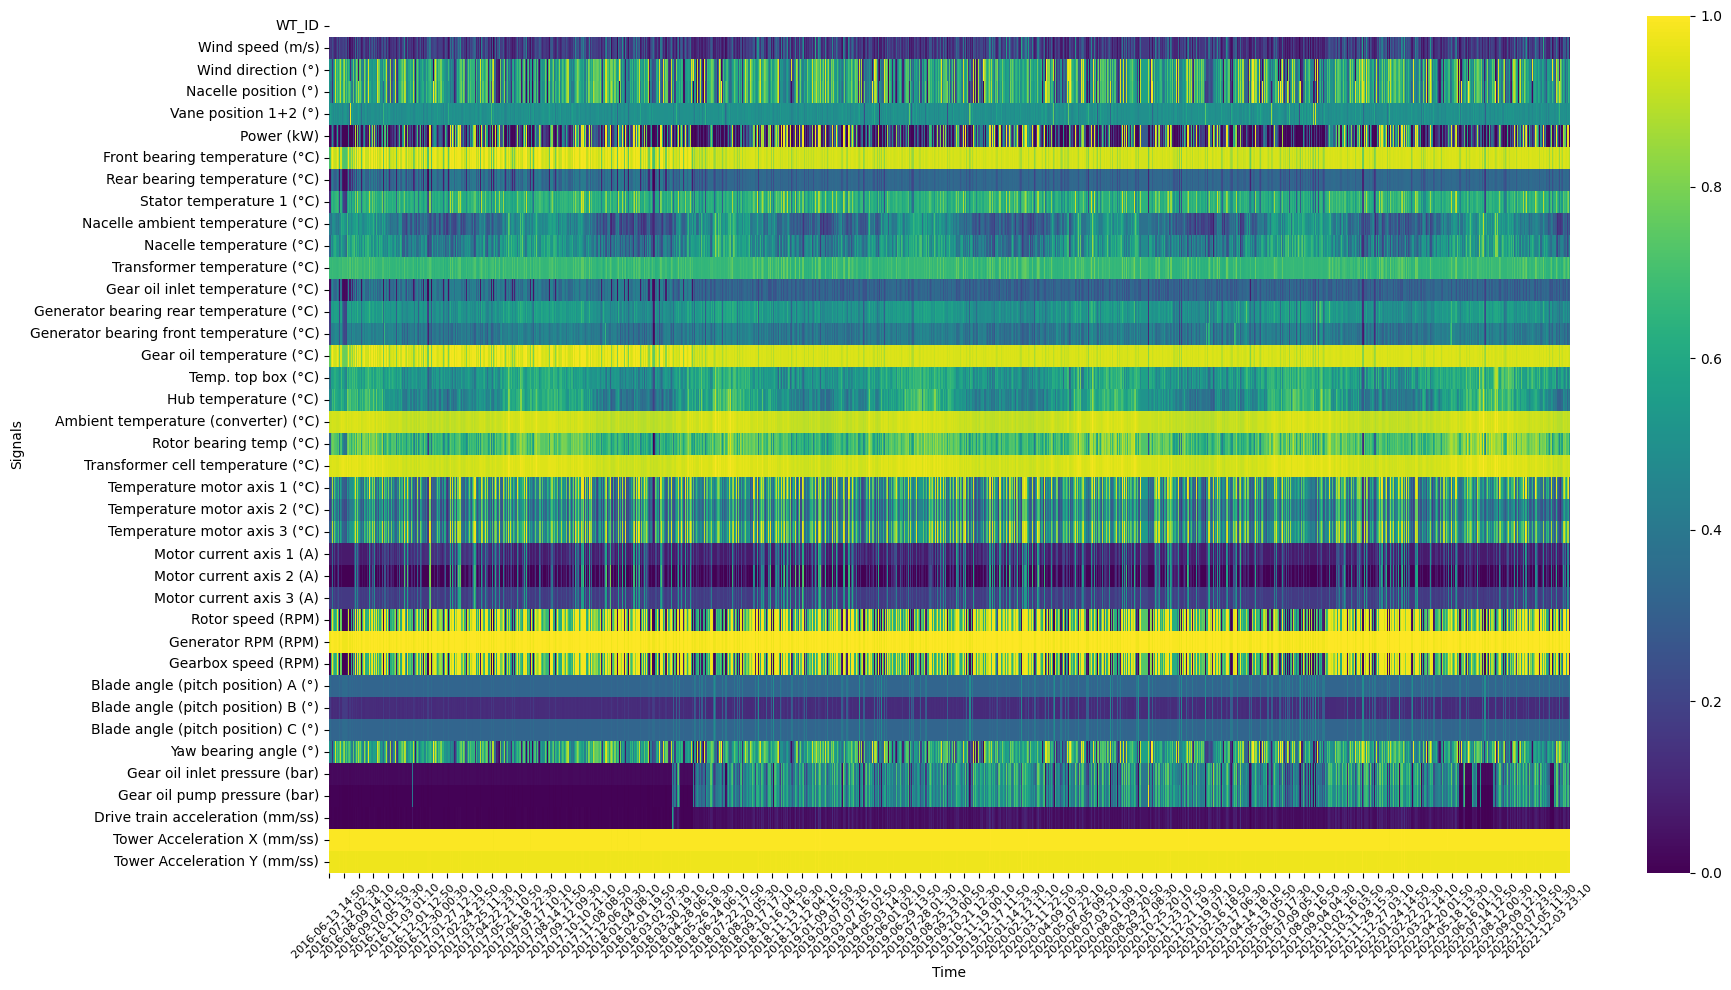

 64%|██████▍   | 9/14 [05:41<03:07, 37.51s/it]

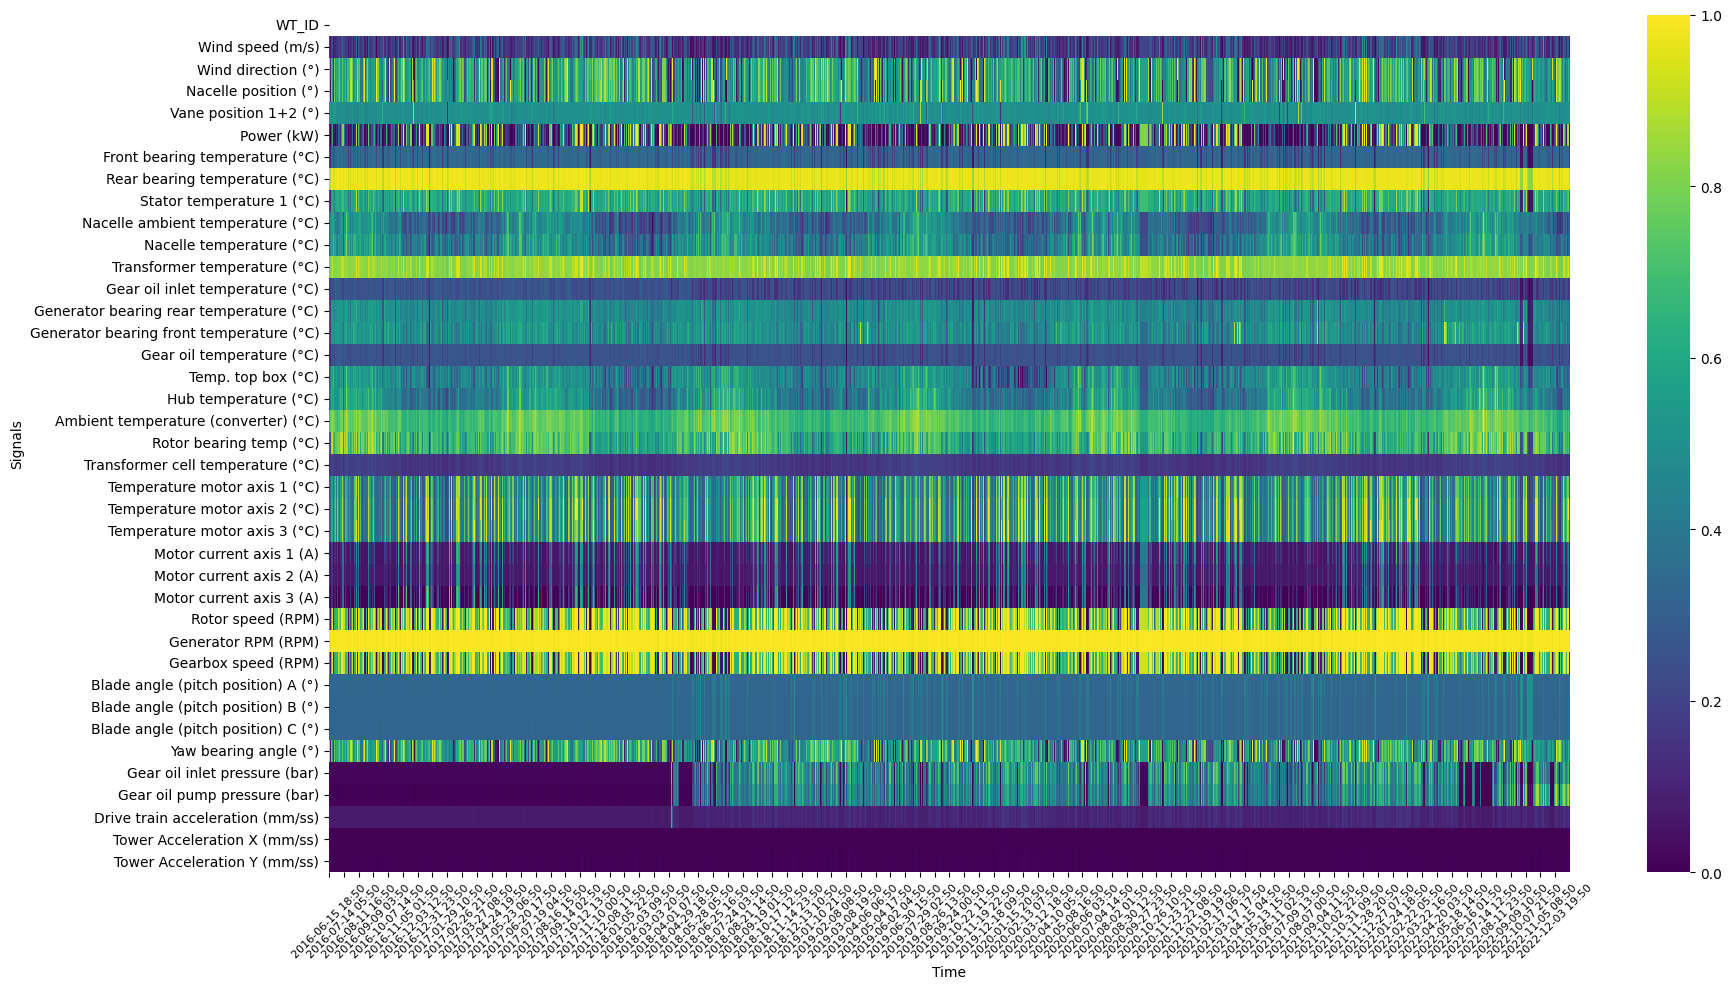

 71%|███████▏  | 10/14 [06:31<02:45, 41.28s/it]

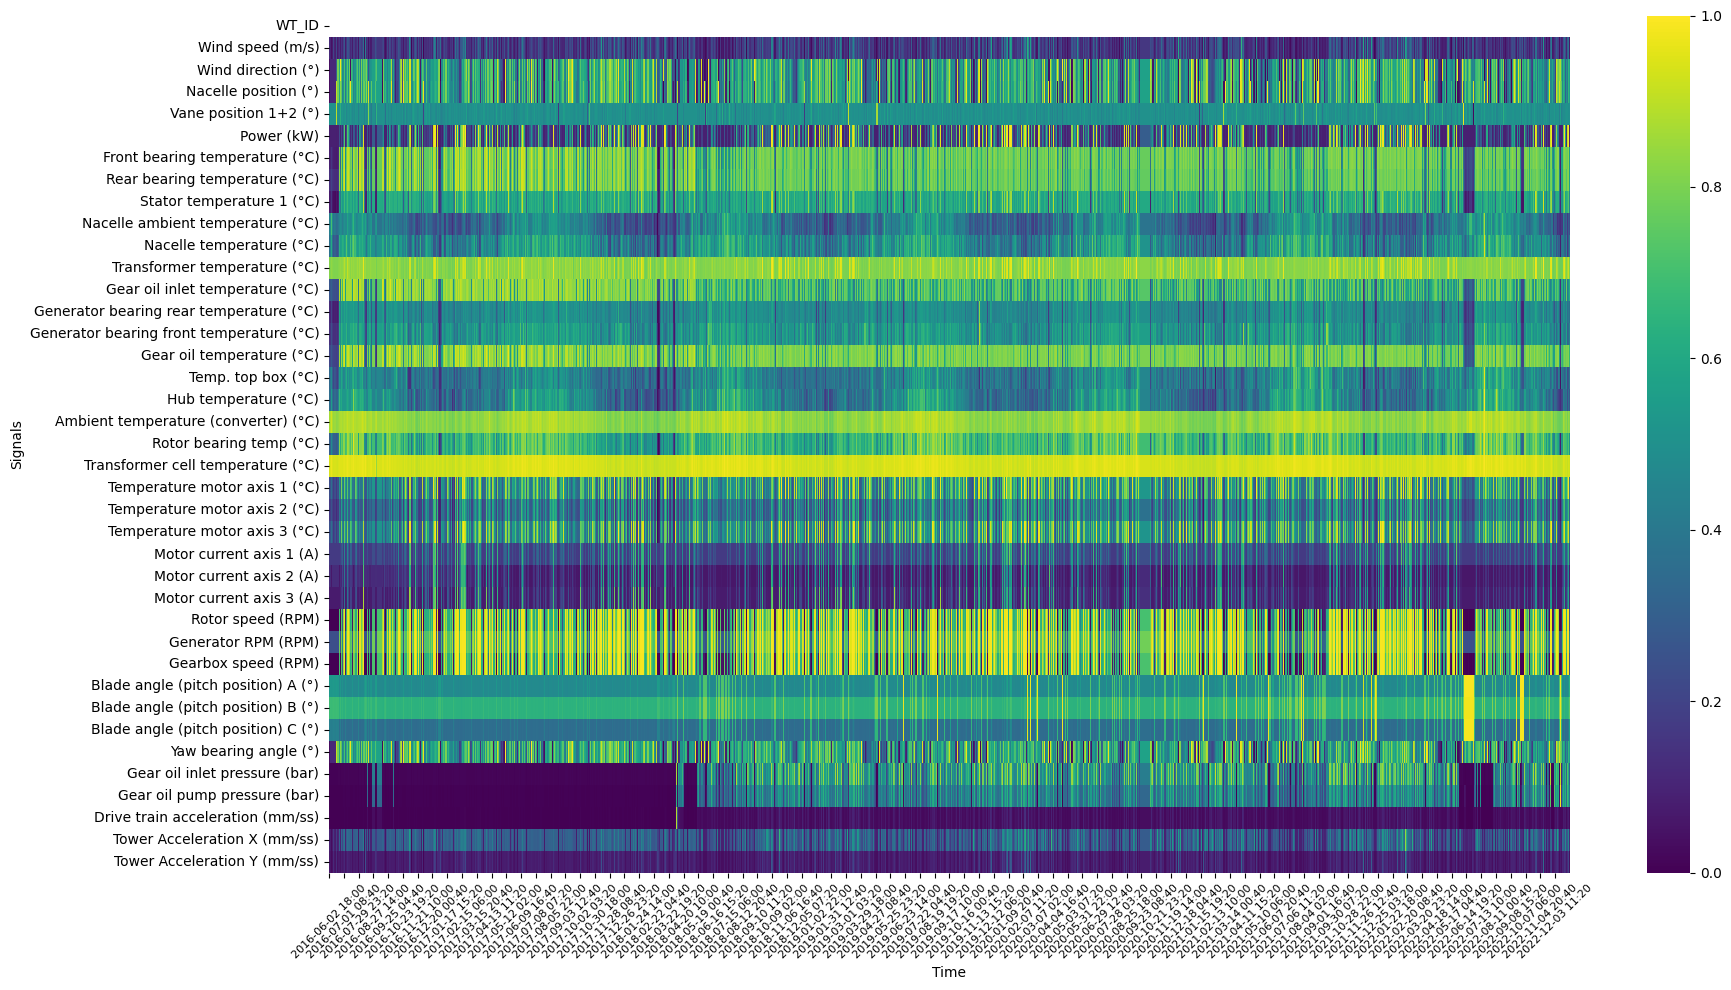

 79%|███████▊  | 11/14 [07:08<02:00, 40.20s/it]

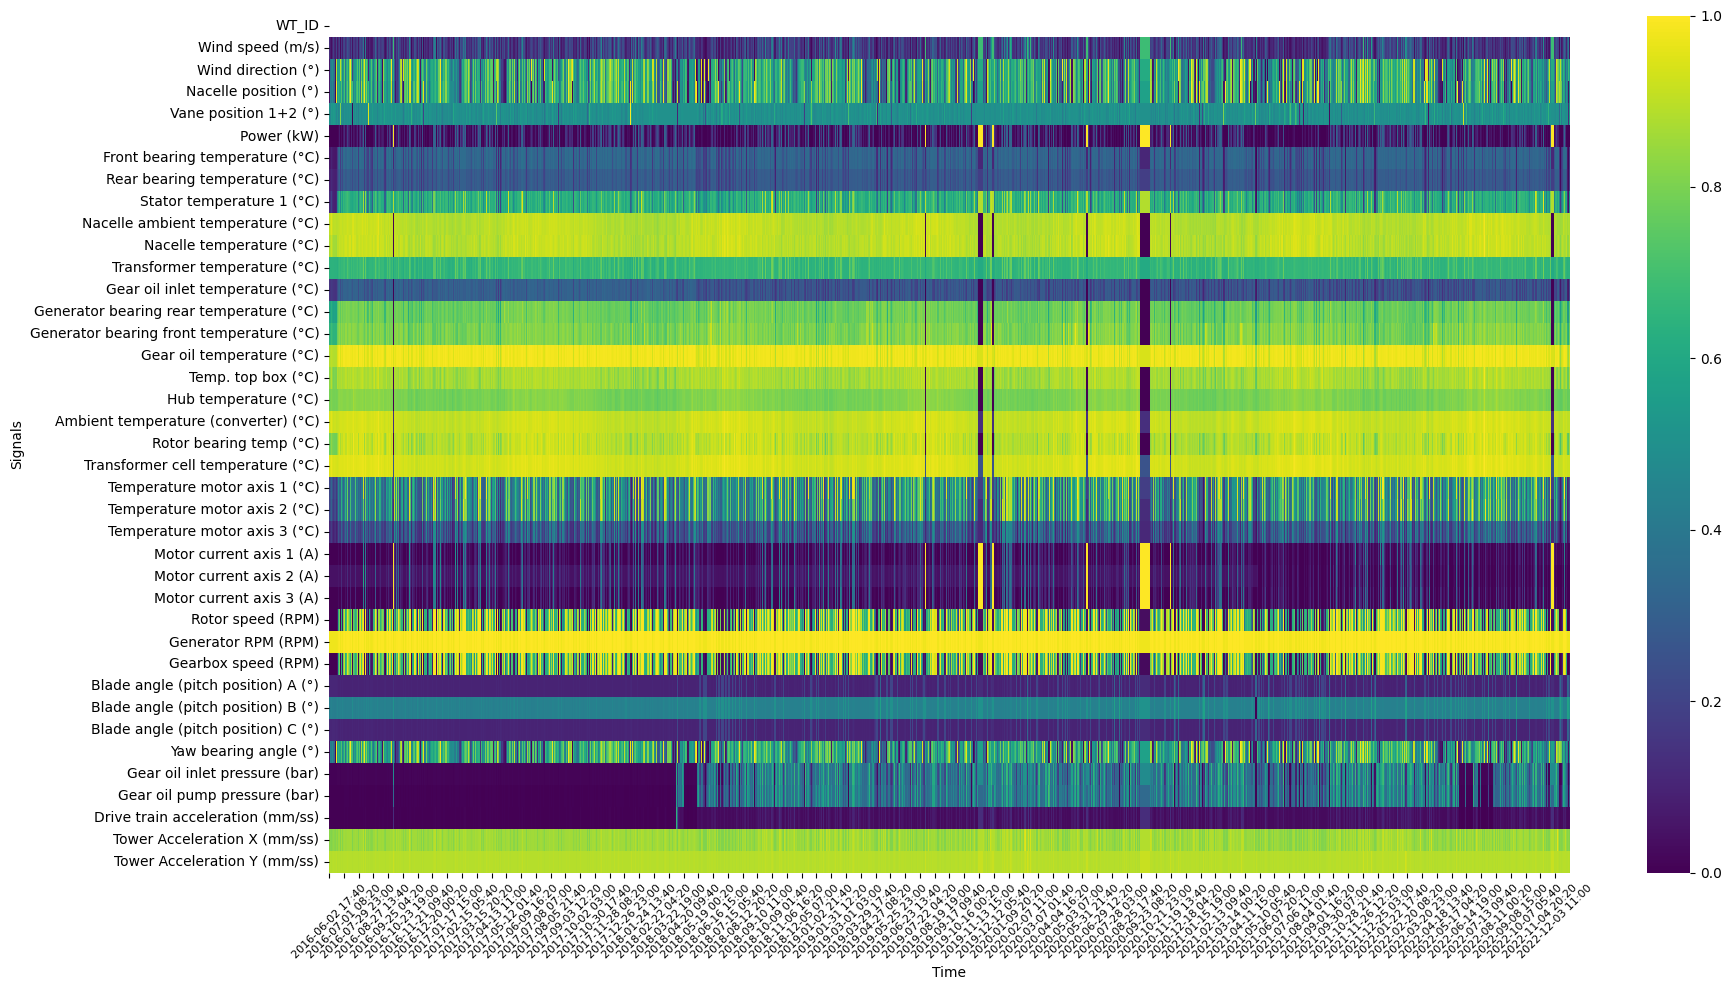

 86%|████████▌ | 12/14 [07:46<01:18, 39.39s/it]

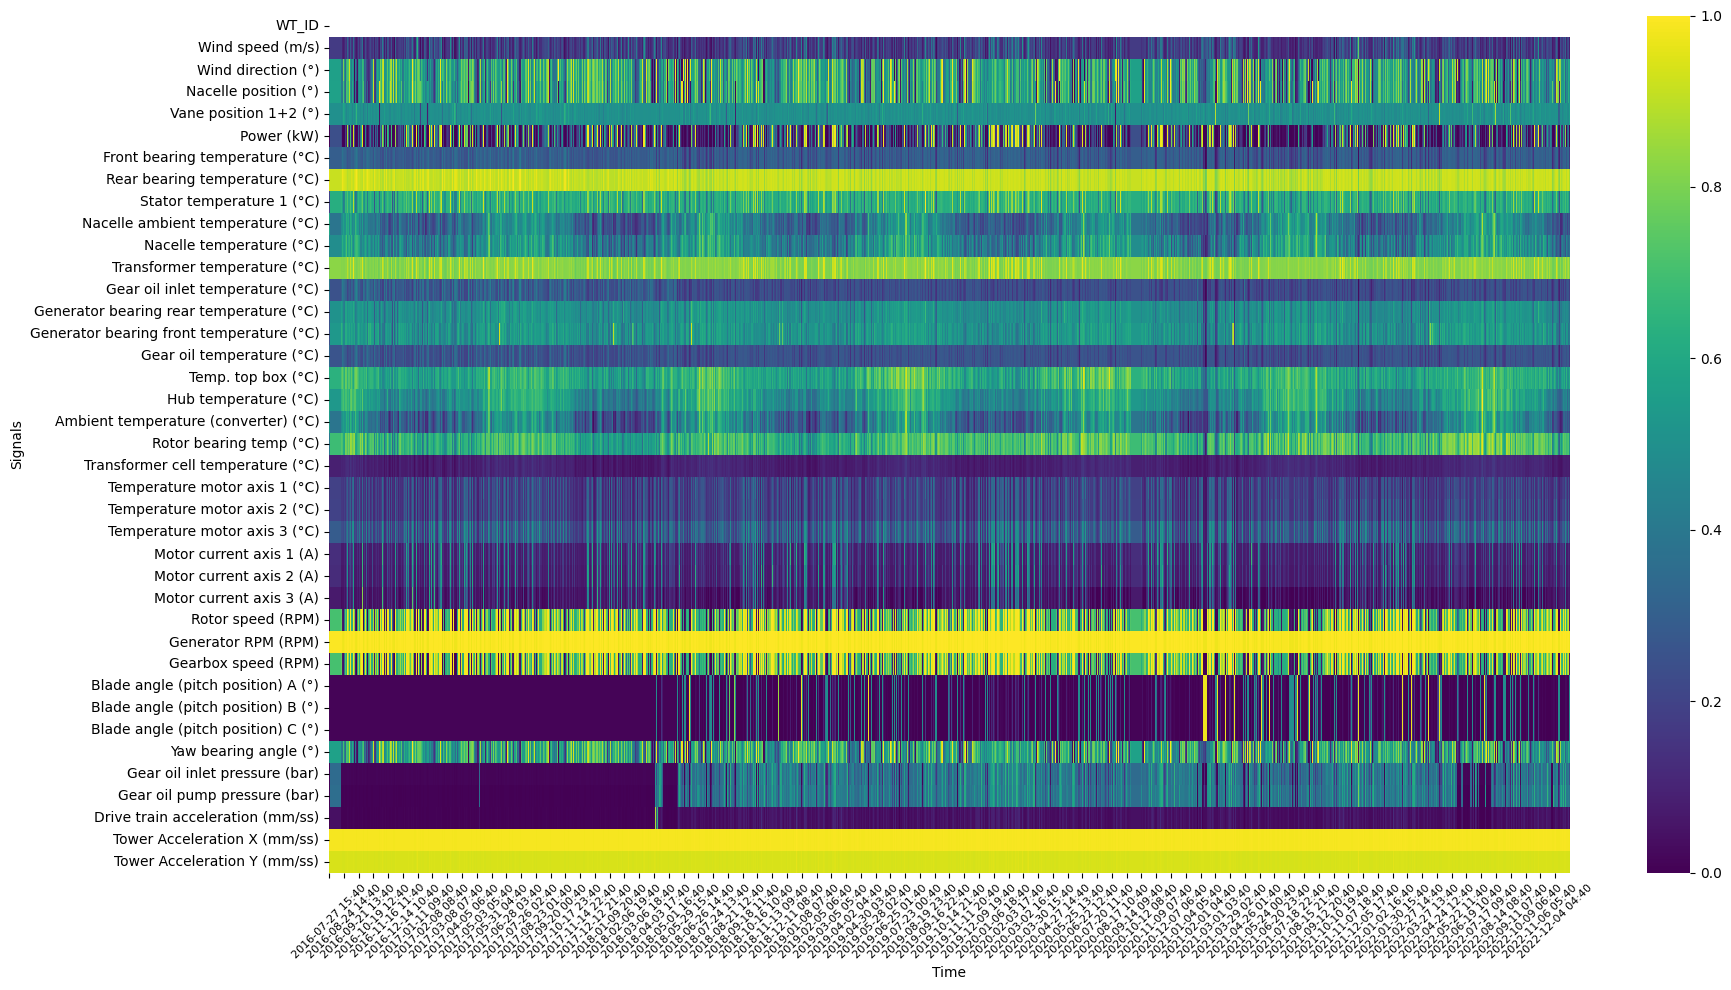

 93%|█████████▎| 13/14 [08:24<00:39, 39.06s/it]

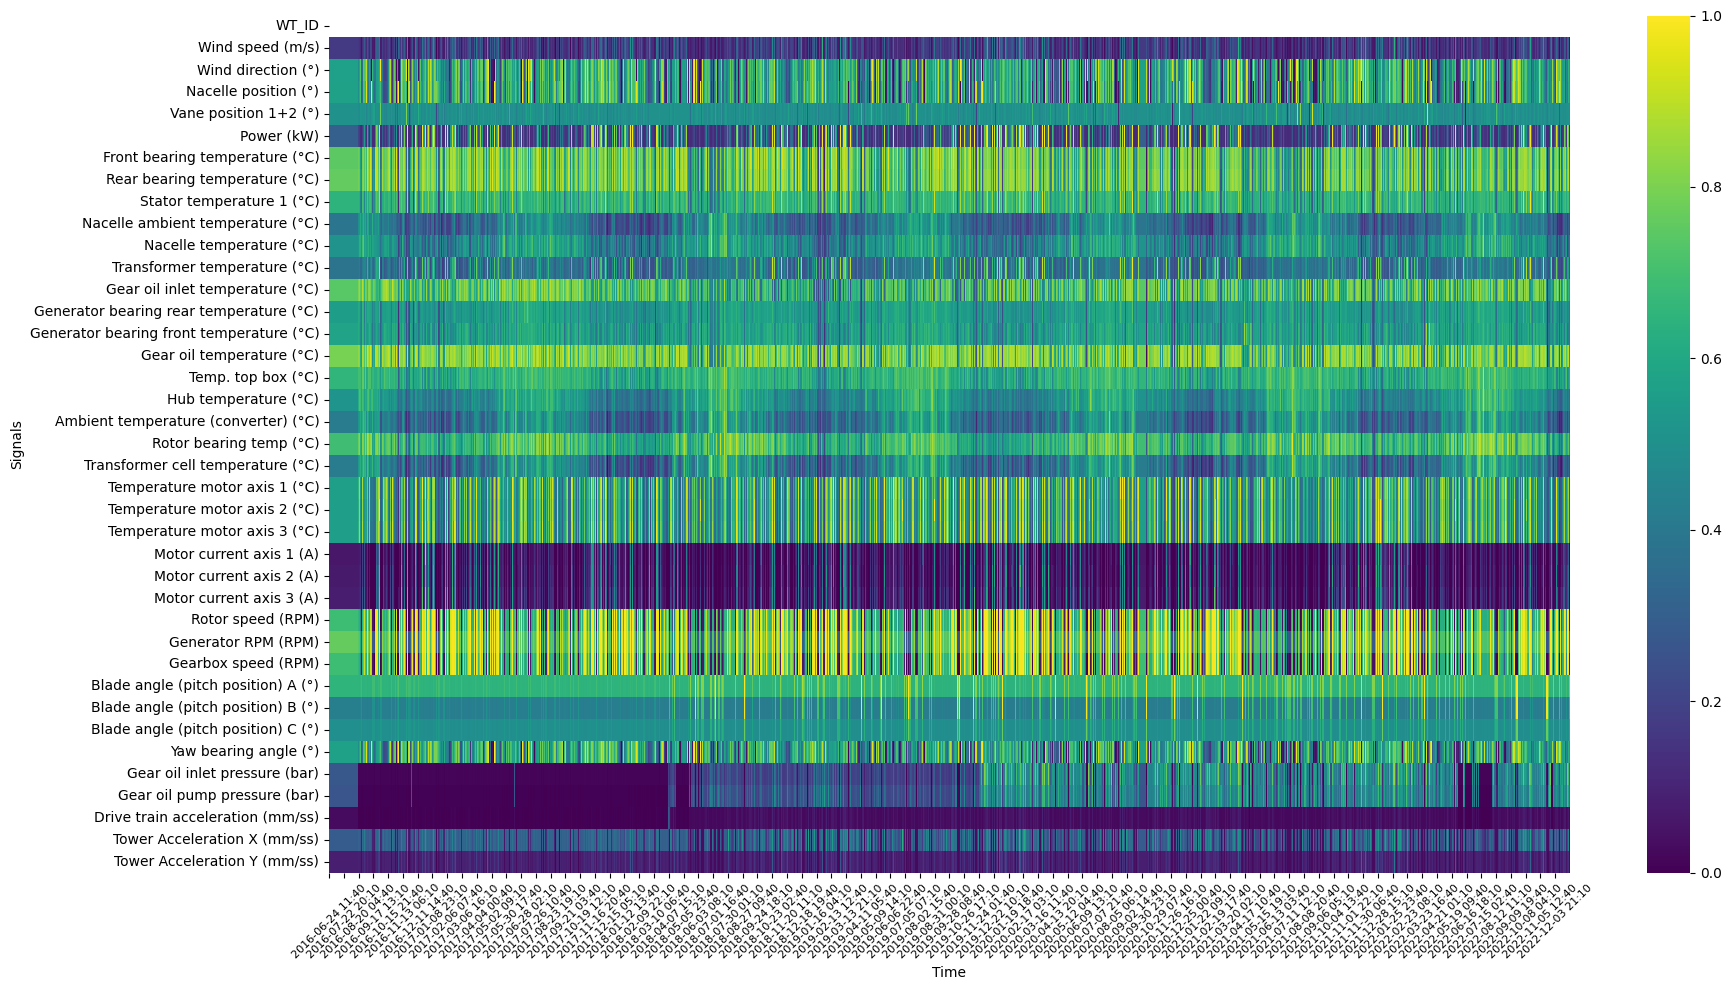

100%|██████████| 14/14 [09:04<00:00, 38.89s/it]


In [10]:

files = glob(os.path.join(preStep4_dict["imputed_path"], "*.csv"))

for f in tqdm(files):
    
    df = pd.read_csv(f)

    data = df.select_dtypes(include=["float", "int"])

    # Min-Max
    normalized = (data - data.min()) / (data.max() - data.min())

    df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")
    normalized.index = df[TS_COL].dt.strftime("%Y-%m-%d %H:%M")

    data_for_plot = normalized.T

    plt.figure(figsize=(19,10))
    sns.heatmap(data_for_plot, cmap="viridis", cbar=True)

    #plt.title("Heatmap of Selected Signals Over Time from Kelmarsh wind turbine 1")
    plt.xlabel("Time")
    plt.ylabel("Signals")
    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout()
    plt.show()

In [11]:
files = glob(os.path.join(preStep4_dict["processed_data_path"], "*.csv"))
df = pd.read_csv(files[0])
len(df.columns)-2

38

#Optional: Deleting old files

In [12]:
# files = glob(os.path.join(preStep4_dict["processed_data_path"], "*.csv"))

# for fp in files:
#     try: 
#         os.remove(fp)
#         print(f"fp deleted.")
#     except:
#         FileNotFoundError
#         print(f"File {fp} not found. ")
#         pass